In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Đọc file và phân tích cột ngày
df = pd.read_csv("ICSA.csv", parse_dates=["observation_date"])

# Đổi tên cột trước cho dễ đọc
df = df.rename(columns={"observation_date": "DATE", "ICSA": "claims"})

# Đặt cột ngày làm chỉ mục thời gian
df.set_index("DATE", inplace=True)

# Thiết lập tần suất tuần (tuần kết thúc vào thứ Bảy)
df = df.asfreq('W-SAT')

# Thông tin về dữ liệu
print(df.info())

# Thống kê mô tả
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3049 entries, 1967-01-07 to 2025-06-07
Freq: W-SAT
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   claims  3049 non-null   int64
dtypes: int64(1)
memory usage: 47.6 KB
None
             claims
count  3.049000e+03
mean   3.622407e+05
std    2.400350e+05
min    1.620000e+05
25%    2.850000e+05
50%    3.400000e+05
75%    3.970000e+05
max    6.137000e+06


# VẼ HAI BIỂU ĐỒ RIÊNG BIỆT

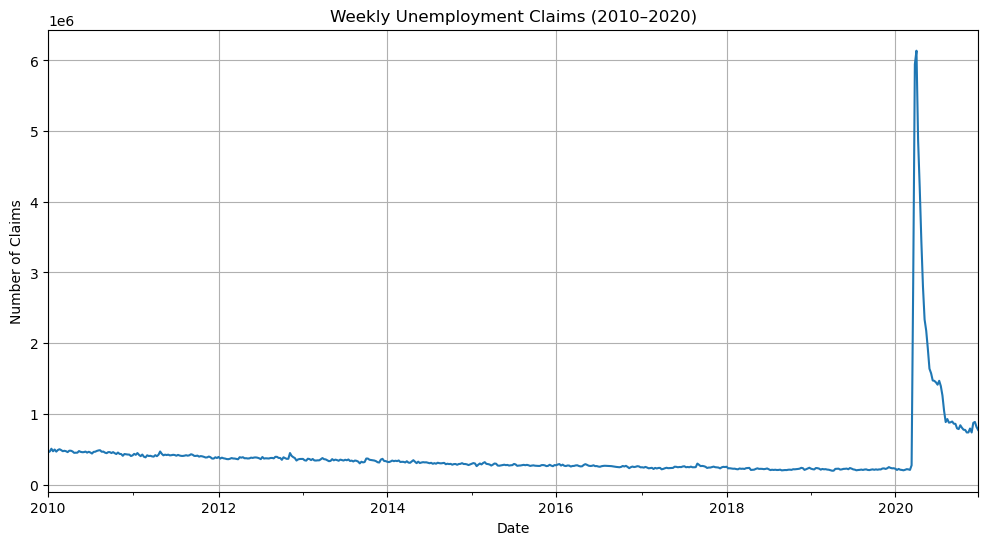

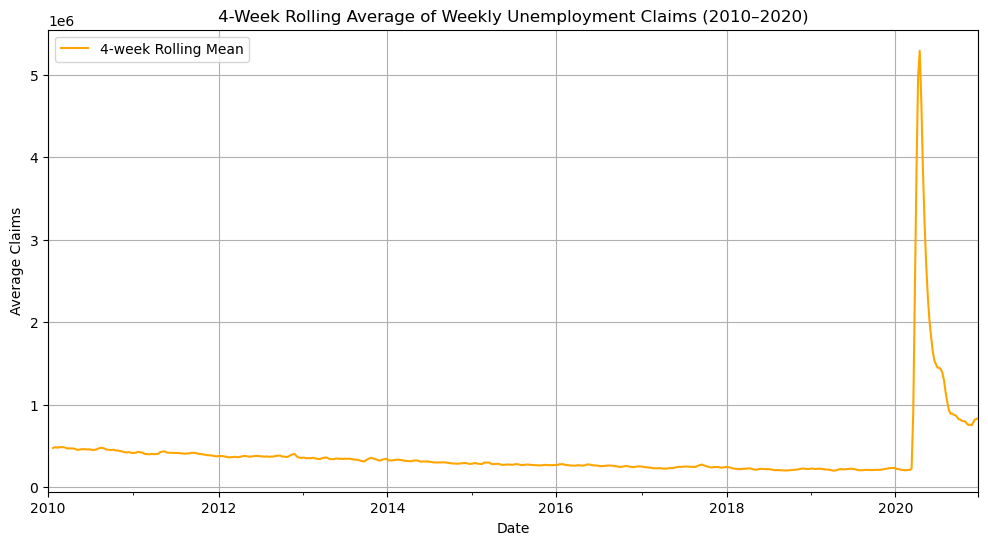

In [13]:
# Chuyển đổi cột index về kiểu datetime nếu chưa có
df.index = pd.to_datetime(df.index)

# Lọc dữ liệu từ 2010 đến 2020
df_filtered = df[(df.index >= '2010-01-01') & (df.index <= '2020-12-31')]

# 1. Vẽ chuỗi gốc trong giai đoạn 2010–2020
df_filtered['claims'].plot(figsize=(12, 6), title="Weekly Unemployment Claims (2010–2020)")
plt.ylabel("Number of Claims")
plt.xlabel("Date")
plt.grid(True)
plt.show()

# 2. Vẽ trung bình trượt 4 tuần trong giai đoạn 2010–2020
df_filtered['claims'].rolling(window=4).mean().plot(figsize=(12, 6), color='orange', label='4-week Rolling Mean')
plt.title("4-Week Rolling Average of Weekly Unemployment Claims (2010–2020)")
plt.ylabel("Average Claims")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()

# VẼ CẢ HAI BIỂU ĐỒ CHUNG

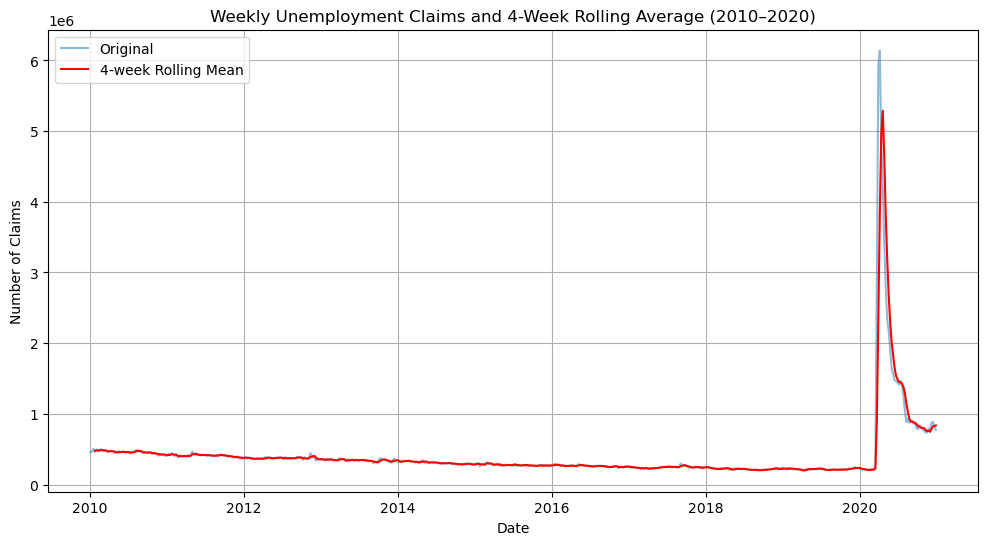

In [16]:
# Lọc khoảng thời gian từ 2010 đến 2020
df_filtered = df[(df.index >= '2010-01-01') & (df.index <= '2020-12-31')]

# Vẽ biểu đồ chuỗi gốc và trung bình trượt
plt.figure(figsize=(12, 6))
plt.plot(df_filtered['claims'], label='Original', alpha=0.5)
plt.plot(df_filtered['claims'].rolling(window=4).mean(), label='4-week Rolling Mean', color='red')
plt.title("Weekly Unemployment Claims and 4-Week Rolling Average (2010–2020)")
plt.ylabel("Number of Claims")
plt.xlabel("Date")
plt.legend()
plt.grid(True)
plt.show()


# Xu hướng (trend) Mùa vụ (seasonal) Nhiễu (residual)

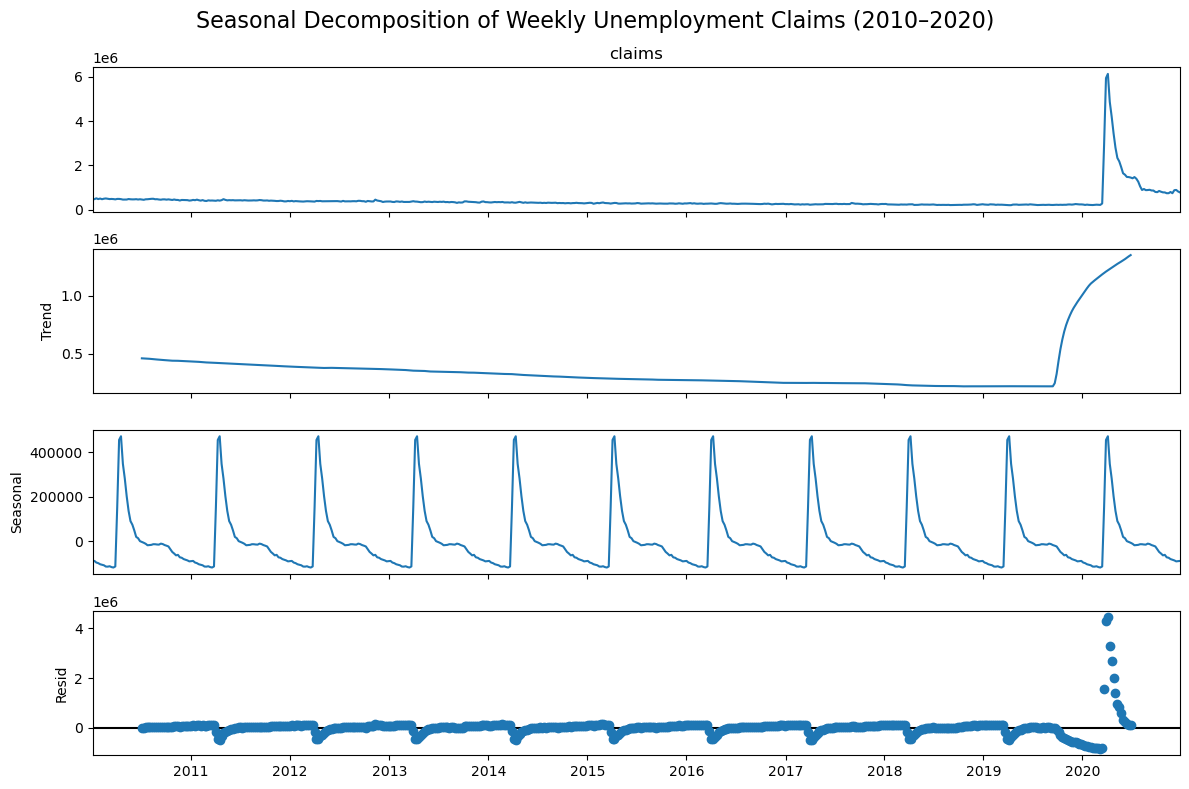

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import pandas as pd

# Đảm bảo index là datetime
df.index = pd.to_datetime(df.index)

# Lọc dữ liệu từ 2010 đến 2020
df_filtered = df[(df.index >= '2010-01-01') & (df.index <= '2020-12-31')]

# Decompose chuỗi với mô hình cộng và chu kỳ mùa vụ là 52 tuần (1 năm)
decomposition = seasonal_decompose(df_filtered['claims'], model='additive', period=52)

# Vẽ kết quả decomposition
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Seasonal Decomposition of Weekly Unemployment Claims (2010–2020)", fontsize=16)
plt.tight_layout()
plt.show()


#  loại bỏ dữ liệu thiếu và chia chuỗi thời gian thành tập huấn luyện và kiểm tra 

In [21]:
# 1. Xử lý dữ liệu thiếu (nếu có)
df = df.dropna()

# 2. Xác định kích thước tập train (80%) và test (20%)
train_size = int(len(df) * 0.8)

# 3. Tách tập train và test
train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()

# 4. In ra kích thước từng tập để kiểm tra
print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")

Train size: 2439
Test size: 610


# kiểm tra tính dừng

In [25]:

df = df.dropna()  # Bỏ giá trị thiếu nếu có
from statsmodels.tsa.stattools import adfuller

# ADF Test
result = adfuller(df['claims'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")


ADF Statistic: -9.1813
p-value: 0.0000


### Vì p-value < 0.05, bạn có thể kết luận rằng chuỗi claims là stationary (chuỗi dừng).

# Biểu đồ ACF/PACF của chuỗi gốc và chuỗi sai phân

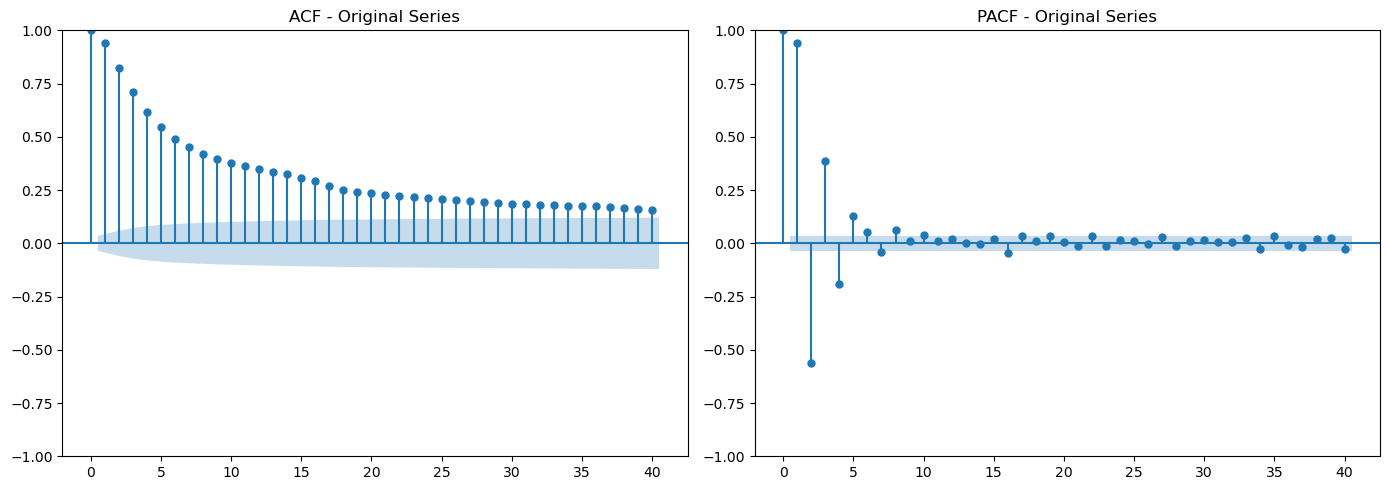

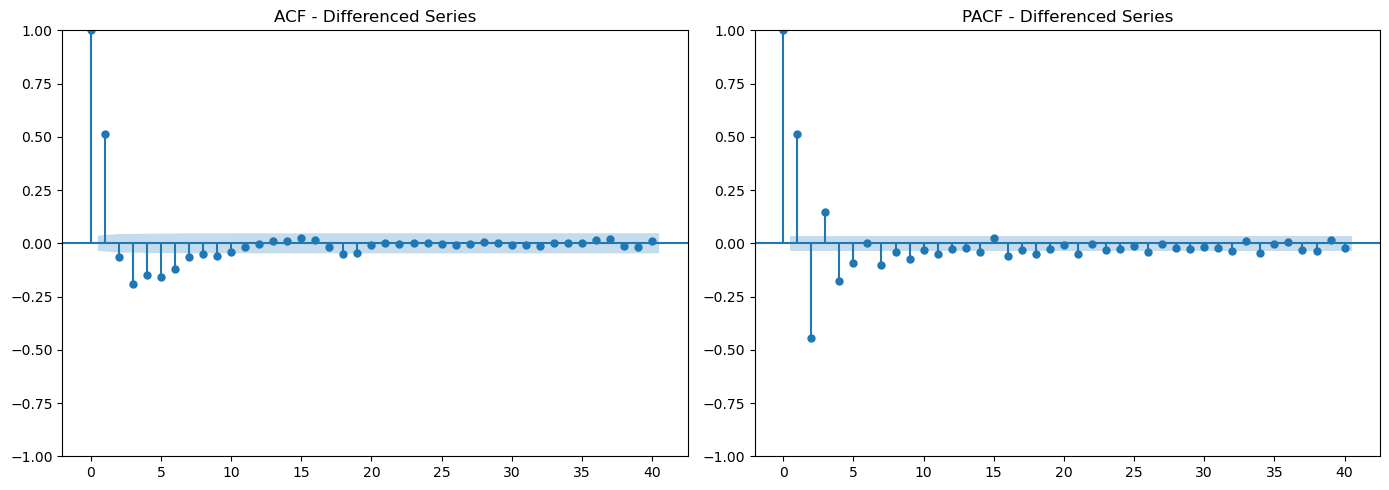

In [29]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF & PACF cho chuỗi gốc
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1)
plot_acf(df['claims'], lags=40, ax=plt.gca(), title='ACF - Original Series')
plt.subplot(1, 2, 2)
plot_pacf(df['claims'], lags=40, ax=plt.gca(), title='PACF - Original Series')
plt.tight_layout()
plt.show()

# ACF & PACF cho chuỗi sai phân
diff_series = df['claims'].diff().dropna()
plt.figure(figsize=(14,5))
plt.subplot(1, 2, 1)
plot_acf(diff_series, lags=40, ax=plt.gca(), title='ACF - Differenced Series')
plt.subplot(1, 2, 2)
plot_pacf(diff_series, lags=40, ax=plt.gca(), title='PACF - Differenced Series')
plt.tight_layout()
plt.show()


# ARIMA

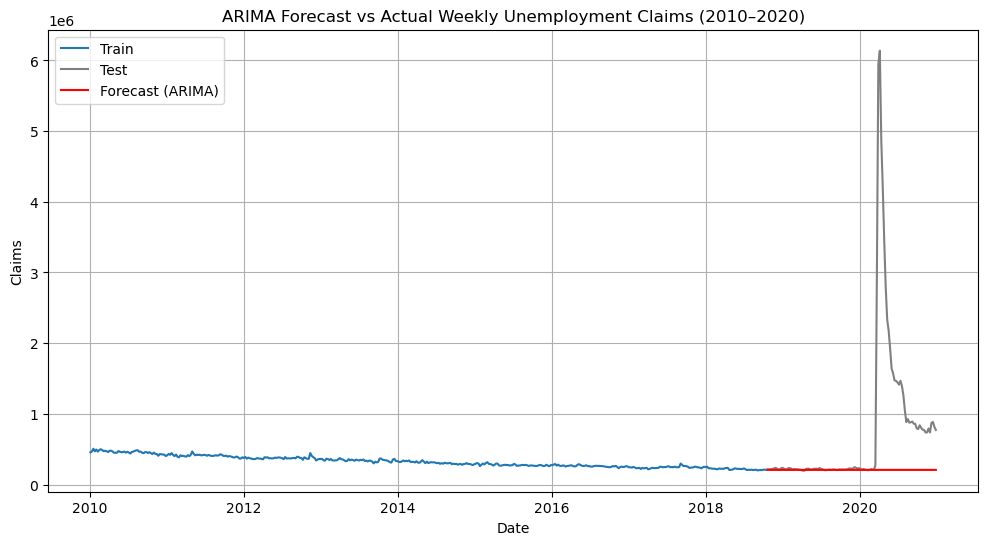

In [277]:
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt
import pandas as pd

# Đảm bảo index là datetime
df.index = pd.to_datetime(df.index)

# Lọc dữ liệu từ 2010 đến 2020
df_filtered = df[(df.index >= '2010-01-01') & (df.index <= '2020-12-31')]

# Chia dữ liệu thành train và test (ví dụ: 80% train, 20% test)
split_index = int(len(df_filtered) * 0.8)
train = df_filtered.iloc[:split_index]
test = df_filtered.iloc[split_index:]

# 1. Khởi tạo mô hình ARIMA: (p=5, d=1, q=0)
model = ARIMA(train['claims'], order=(5, 1, 0))
model_fit = model.fit()

# 2. Dự báo số bước bằng độ dài tập test
forecast_arima = model_fit.forecast(steps=len(test))

# 3. Đặt index của forecast giống test
forecast_arima.index = test.index

# 4. Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(train['claims'], label='Train')
plt.plot(test['claims'], label='Test', color='gray')
plt.plot(forecast_arima, label='Forecast (ARIMA)', color='red')
plt.title("ARIMA Forecast vs Actual Weekly Unemployment Claims (2010–2020)")
plt.xlabel("Date")
plt.ylabel("Claims")
plt.legend()
plt.grid(True)
plt.show()


# ETS – Exponential Smoothing

Forecast values:
 2018-10-20    207343.835715
2018-10-27    206703.370079
2018-11-03    210853.370242
2018-11-10    205374.785913
2018-11-17    205764.904994
Freq: W-SAT, dtype: float64


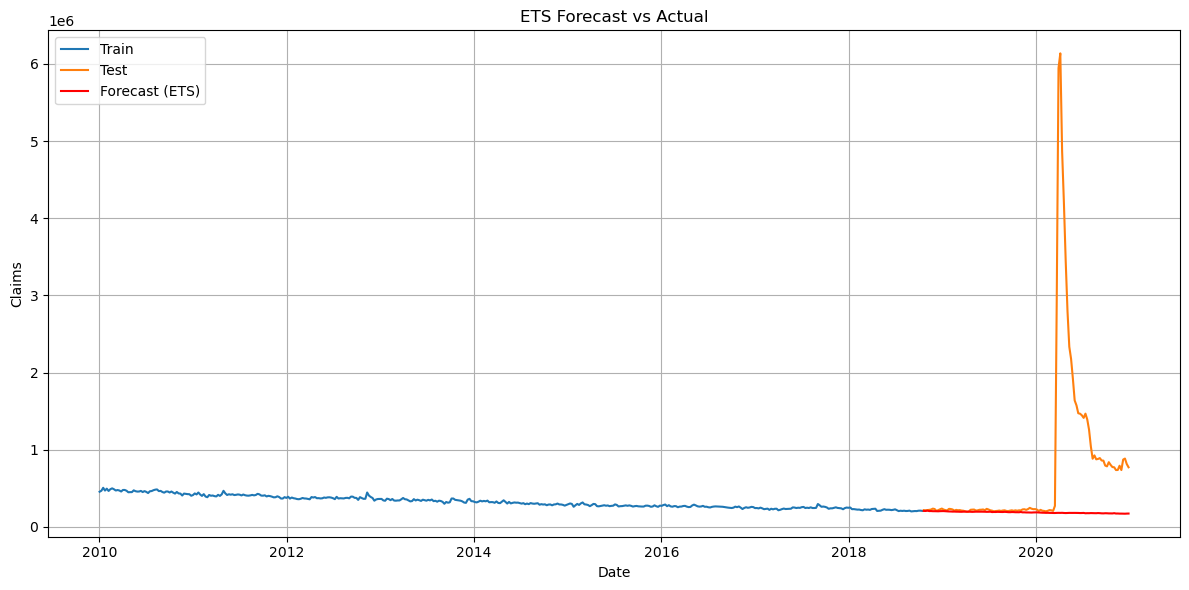

In [280]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt

train_series = train['claims']
test_series = test['claims']

model_ets = ExponentialSmoothing(
    train_series,
    trend='add',
    seasonal='add',
    seasonal_periods=52,
    initialization_method="estimated",
    use_boxcox=True
)

fit_ets = model_ets.fit()
forecast_ets = fit_ets.forecast(steps=len(test_series))

# In kết quả dự báo đầu tiên
print("Forecast values:\n", forecast_ets.head())

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(train_series.index, train_series, label='Train')
plt.plot(test_series.index, test_series, label='Test')
plt.plot(test_series.index, forecast_ets, label='Forecast (ETS)', color='red')
plt.title('ETS Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Claims')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# So sánh hiệu quả hai mô hình dự báo thời gian: ARIMA và ETS (Exponential Smoothing)

MSE ARIMA: 1430814936127.3337
MSE ETS: 1460419512344.6472


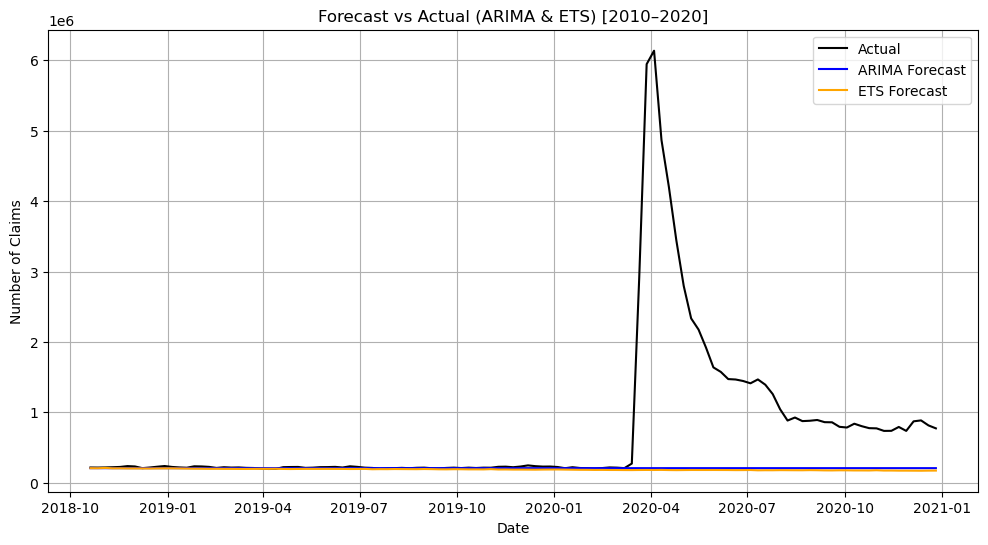

In [283]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import pandas as pd

# Giả sử df đã có sẵn, lọc từ 2010 đến 2020
df.index = pd.to_datetime(df.index)
df_filtered = df[(df.index >= '2010-01-01') & (df.index <= '2020-12-31')]

# Tách lại train-test
split_index = int(len(df_filtered) * 0.8)
train = df_filtered.iloc[:split_index]
test = df_filtered.iloc[split_index:]

# Giả sử bạn đã có forecast_arima và forecast_ets dựa trên train và test này

# Tính MSE
mse_arima = mean_squared_error(test['claims'], forecast_arima)
mse_ets = mean_squared_error(test['claims'], forecast_ets)

print("MSE ARIMA:", mse_arima)
print("MSE ETS:", mse_ets)

# Vẽ biểu đồ
plt.figure(figsize=(12, 6))
plt.plot(test.index, test['claims'], label="Actual", color='black')
plt.plot(test.index, forecast_arima, label="ARIMA Forecast", color='blue')
plt.plot(test.index, forecast_ets, label="ETS Forecast", color='orange')
plt.title("Forecast vs Actual (ARIMA & ETS) [2010–2020]")
plt.xlabel("Date")
plt.ylabel("Number of Claims")
plt.legend()
plt.grid(True)
plt.show()

# Chuẩn đoán phần dư sau khi fit  ARIMA

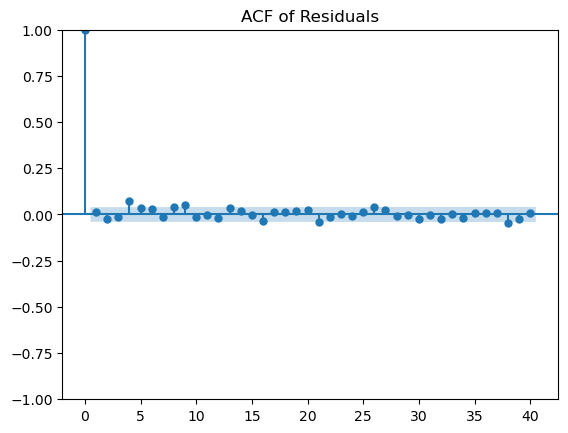

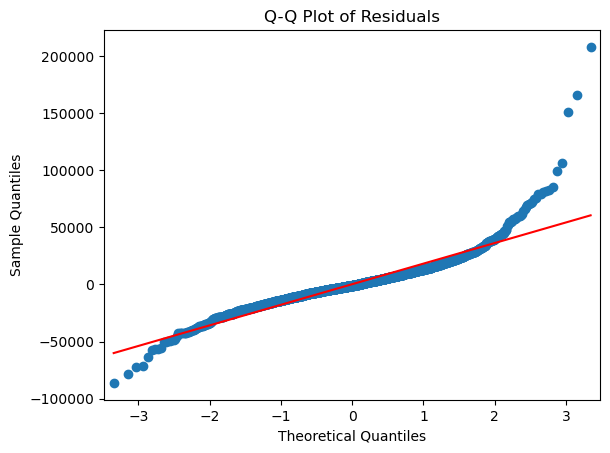

Ljung-Box Test:
       lb_stat  lb_pvalue
10  31.283401   0.000527
20  41.396679   0.003312
30  53.818872   0.004816


In [40]:
from statsmodels.tsa.arima.model import ARIMA

# Chia dữ liệu train/test
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Fit ARIMA model
model = ARIMA(train['claims'], order=(1, 1, 1))  # sửa lại (p,d,q) nếu cần
model_fit = model.fit()

# Sau khi đã fit ARIMA model:
residuals = model_fit.resid

# ACF của phần dư
plot_acf(residuals, lags=40)
plt.title('ACF of Residuals')
plt.show()

# Q-Q plot để kiểm tra phân phối chuẩn của phần dư
from statsmodels.graphics.gofplots import qqplot
qqplot(residuals, line='s')
plt.title('Q-Q Plot of Residuals')
plt.show()

# Ljung-Box test để kiểm tra phần dư có phải white noise không
from statsmodels.stats.diagnostic import acorr_ljungbox
lb_test = acorr_ljungbox(residuals, lags=[10, 20, 30], return_df=True)
print("Ljung-Box Test:\n", lb_test)


# Tính sai số dự báo (Evaluation) Đo lường chất lượng dự báo bằng RMSE, MAE, MAPE:

In [43]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Train/test split
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Fit ARIMA(1,1,1)
model = ARIMA(train['claims'], order=(1, 1, 1))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=len(test))

# Evaluate
mae = mean_absolute_error(test['claims'], forecast)
rmse = mean_squared_error(test['claims'], forecast, squared=False)
mape = (abs(test['claims'] - forecast) / test['claims']).mean() * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

# Residual diagnostics (vẫn dùng từ model_fit của ARIMA(1,1,1))
residuals = model_fit.resid


MAE: 170094.69
RMSE: 509702.79
MAPE: 35.98%


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# Bổ sung thêm chỉ số sai số MAPE

In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(test['claims'], forecast)
rmse = mean_squared_error(test['claims'], forecast, squared=False)
mape = (abs(test['claims'] - forecast) / test['claims']).mean() * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


MAE: 170094.69
RMSE: 509702.79
MAPE: 35.98%


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


# So sánh với mô hình khác

Tên các cột trong train: Index(['observation_date', 'ICSA'], dtype='object')
Số lượng quan sát trong train: 2439
Seasonal periods: 52


C:\Users\Lenovo\anaconda3\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:918: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Kết quả tối ưu:  message: Inequality constraints incompatible
 success: False
  status: 4
     fun: 784210159668.5792
       x: [ 6.061e-01  1.000e-04 ... -1.382e+03  1.098e+04]
     nit: 1
     jac: [ 5.108e+09 -4.844e+11 ... -9.011e+04  2.621e+05]
    nfev: 58
    njev: 1


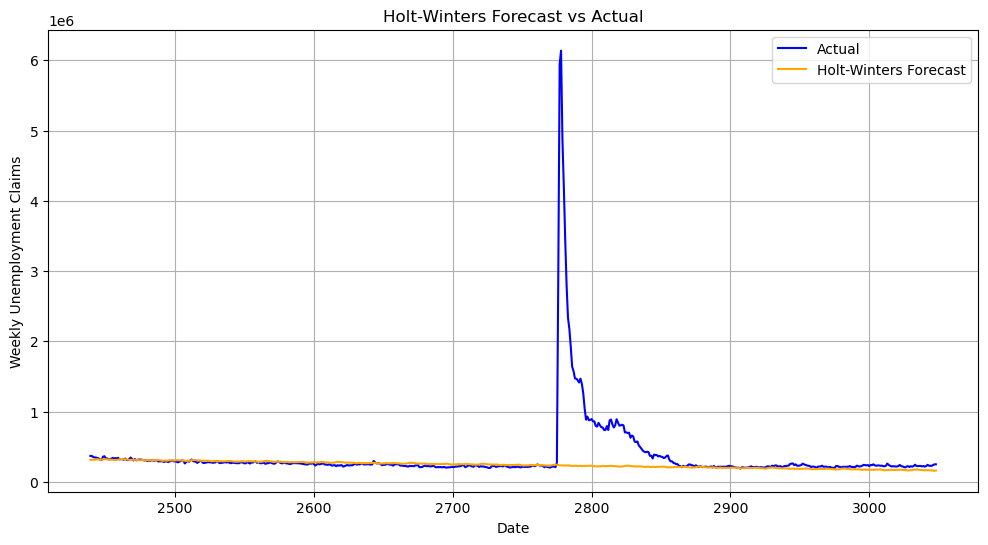

[Holt-Winters] MAE: 141195.93, RMSE: 524329.53


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


In [177]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

print("Tên các cột trong train:", train.columns)
print("Số lượng quan sát trong train:", len(train))

# Lấy dữ liệu chuỗi thời gian
y_train = train['ICSA']
y_test = test['ICSA']

# Kiểm tra độ dài để quyết định seasonal_periods
seasonal_periods = 52 if len(train) >= 104 else None
print("Seasonal periods:", seasonal_periods)

# Khởi tạo mô hình Holt-Winters
model_hw = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal='add' if seasonal_periods else None,
    seasonal_periods=seasonal_periods
)

# Fit mô hình
model_hw_fit = model_hw.fit(optimized=True)

# Kiểm tra hội tụ
print("Kết quả tối ưu:", model_hw_fit.mle_retvals)

# Dự báo trên tập test
forecast_hw = model_hw_fit.forecast(len(test))

# Vẽ so sánh thực tế vs dự báo
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual', color='blue')
plt.plot(y_test.index, forecast_hw, label='Holt-Winters Forecast', color='orange')
plt.title('Holt-Winters Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Weekly Unemployment Claims')
plt.legend()
plt.grid(True)
plt.show()

# Tính sai số
mae_hw = mean_absolute_error(y_test, forecast_hw)
rmse_hw = mean_squared_error(y_test, forecast_hw, squared=False)
print(f"[Holt-Winters] MAE: {mae_hw:.2f}, RMSE: {rmse_hw:.2f}")


#  Kiểm định Augmented Dickey-Fuller (ADF test) để kiểm tra tính dừng (stationarity) của chuỗi thời gian

In [22]:
# Chuyển cột thời gian và đặt làm index
from statsmodels.tsa.stattools import adfuller
df = pd.read_csv("ICSA.csv", parse_dates=["observation_date"])
df['observation_date'] = pd.to_datetime(df['observation_date'])
df.set_index('observation_date', inplace=True)

# Kiểm tra tính dừng bằng Augmented Dickey-Fuller test
adf_result = adfuller(df['ICSA'])
print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
for key, value in adf_result[4].items():
    print(f"Critical Value ({key}): {value}")
if adf_result[1] < 0.05:
    print("✅ Chuỗi dừng (stationary).")
else:
    print("❌ Chuỗi không dừng (non-stationary).")

ADF Statistic: -9.181301809699749
p-value: 2.2481270561470056e-15
Critical Value (1%): -3.432503613730928
Critical Value (5%): -2.8624915293046693
Critical Value (10%): -2.5672765233028003
✅ Chuỗi dừng (stationary).


# Giúp quan sát xu hướng biến đổi trung bình hàng tháng và hàng quý của dữ liệu ICSA trong giai đoạn 2010-2020

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4300\2046130051.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_series = df['ICSA'].resample('M').mean()
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_4300\2046130051.py:3: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  quarterly_series = df['ICSA'].resample('Q').mean()


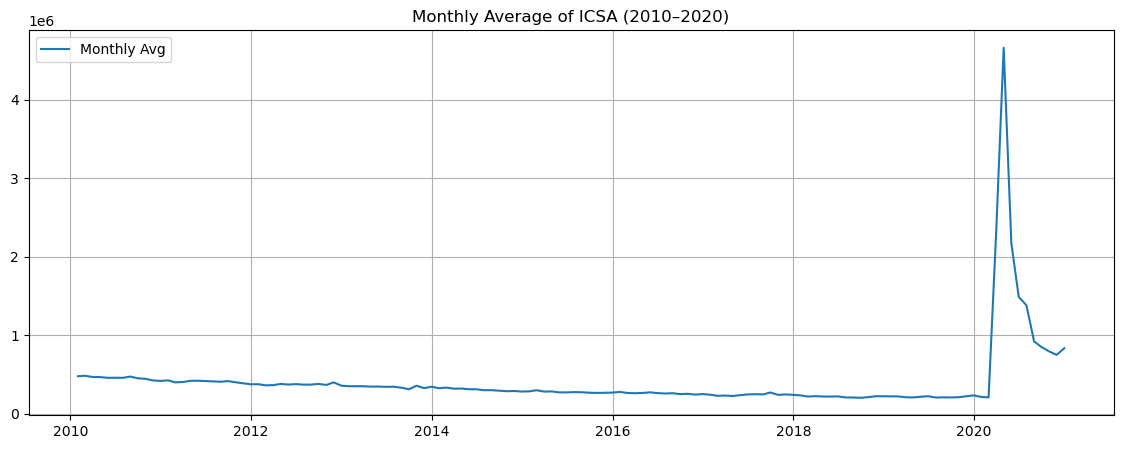

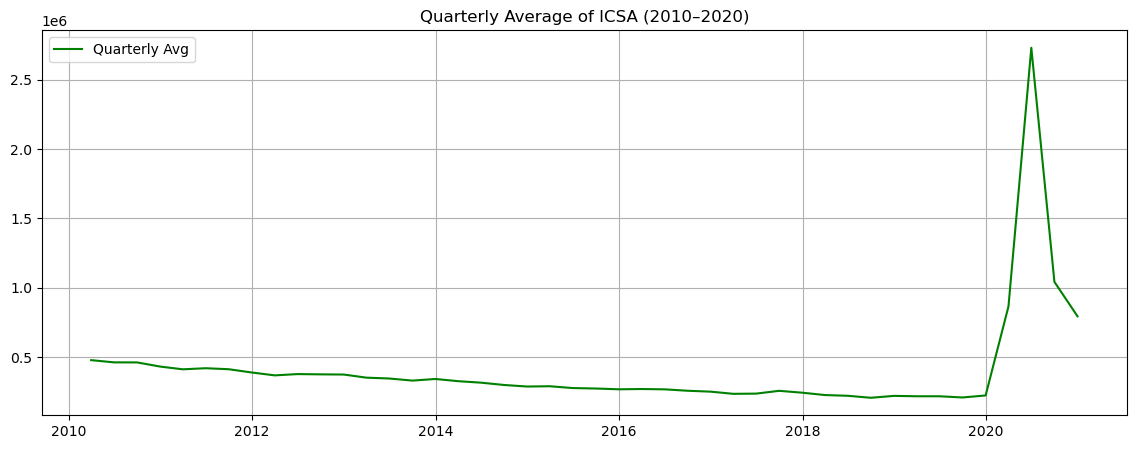

In [24]:
# Trung bình theo tháng và quý
monthly_series = df['ICSA'].resample('M').mean()
quarterly_series = df['ICSA'].resample('Q').mean()

# Lọc từ 2010 đến 2020
monthly_filtered = monthly_series['2010':'2020']
quarterly_filtered = quarterly_series['2010':'2020']

# Vẽ biểu đồ trung bình theo tháng
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(monthly_filtered, label='Monthly Avg')
plt.title('Monthly Average of ICSA (2010–2020)')
plt.grid(True)
plt.legend()
plt.show()

# Vẽ biểu đồ trung bình theo quý
plt.figure(figsize=(14, 5))
plt.plot(quarterly_filtered, label='Quarterly Avg', color='green')
plt.title('Quarterly Average of ICSA (2010–2020)')
plt.grid(True)
plt.legend()
plt.show()


# Xác định các điểm bất thường (anomalies)

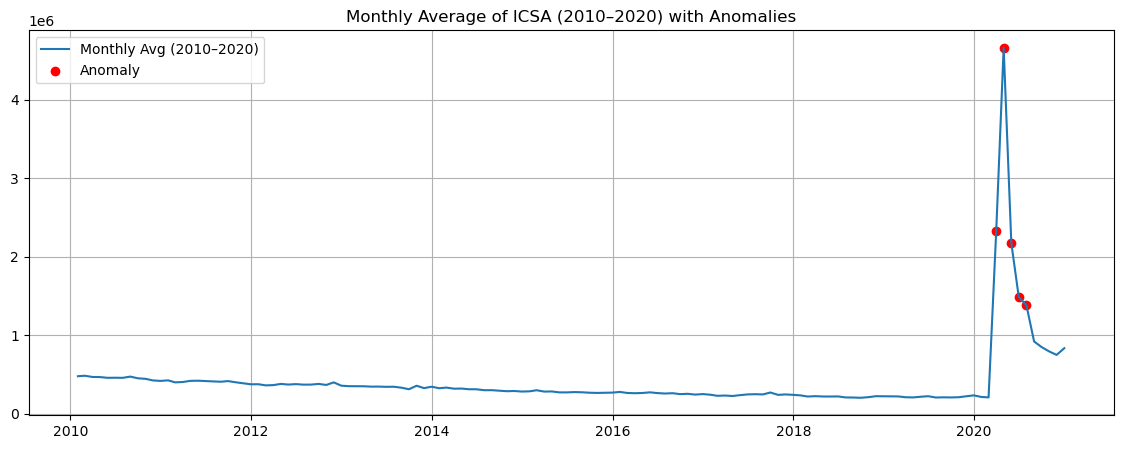

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Tính trung bình và độ lệch chuẩn toàn chuỗi monthly_series
monthly_mean = monthly_series.mean()
monthly_std = monthly_series.std()

# Tính z-score
z_scores = (monthly_series - monthly_mean) / monthly_std

# Lọc chuỗi từ 2010 đến 2020
monthly_filtered = monthly_series['2010':'2020']
z_filtered = z_scores['2010':'2020']

# Lọc các điểm bất thường (z > 3 hoặc z < -3)
anomalies = monthly_filtered[(z_filtered > 3) | (z_filtered < -3)]

# Vẽ biểu đồ
plt.figure(figsize=(14, 5))
plt.plot(monthly_filtered, label='Monthly Avg (2010–2020)')
plt.scatter(anomalies.index, anomalies, color='red', label='Anomaly')
plt.title('Monthly Average of ICSA (2010–2020) with Anomalies')
plt.legend()
plt.grid(True)
plt.show()


## từ năm 2020 trở đi

Các điểm bất thường từ 2020 trở đi:
                  ICSA
observation_date      
2020-01-04         NaN
2020-01-11         NaN
2020-01-18         NaN
2020-01-25         NaN
2020-02-01         NaN
...                ...
2025-05-10         NaN
2025-05-17         NaN
2025-05-24         NaN
2025-05-31         NaN
2025-06-07         NaN

[284 rows x 1 columns]


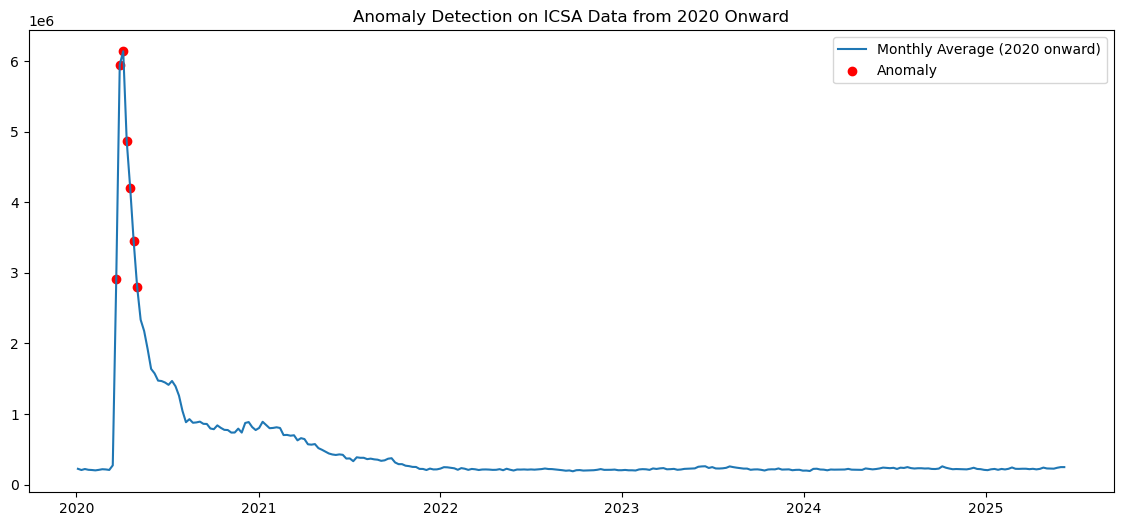

In [28]:
# Giả sử 'data' là pandas Series của bạn, index là datetime, giá trị là số liệu ICSA hàng tháng
# Ví dụ: data = pd.Series(...)

# Lọc dữ liệu từ 2020 trở đi
data_2020 = df['2020':]

# Tính trung bình và độ lệch chuẩn của dữ liệu từ 2020
mean_2020 = data_2020.mean()
std_2020 = data_2020.std()

# Tính z-score
z_scores = (data_2020 - mean_2020) / std_2020

# Lọc các điểm bất thường (z > 3 hoặc z < -3)
anomalies = data_2020[(z_scores > 3) | (z_scores < -3)]

print("Các điểm bất thường từ 2020 trở đi:")
print(anomalies)

# Vẽ đồ thị với điểm bất thường
plt.figure(figsize=(14,6))
plt.plot(data_2020.index, data_2020.values, label='Monthly Average (2020 onward)')
plt.scatter(anomalies.index, anomalies.values, color='red', label='Anomaly')
plt.title('Anomaly Detection on ICSA Data from 2020 Onward')
plt.legend()
plt.show()
